# Storm-Shy 🌊
### Cut your exposure when the market gets loud — does it actually pay, or is it just selling low?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Free lunch?: Risk-managed](https://img.shields.io/badge/Free_lunch%3F-Risk--managed-8b949e?style=flat-square)

Fifteen studies on this desk, fifteen ideas put to the sword — and almost all of them turned out to be **mirages**. This one is different, and it's the one we've been circling the whole time. Back in [Study 12](../../12-paper-prophet/) we tore down a fancy ARIMA+GARCH forecaster and found the *only* real thing inside it was a humble trick: **when markets get volatile, hold less; when they go quiet, hold more.** We called it "vol-targeting in a trenchcoat" and moved on. Now we give that trick the lead role.

The pitch (Moreira & Muir, *Journal of Finance* 2017): you don't need to forecast *returns* — nobody reliably can — you only need to forecast **risk**, and risk is the single most predictable thing in markets. Volatility *clusters*: a wild day is followed by wild days, a calm stretch by calm. So size your position by the **inverse** of recent volatility, and you quietly dodge the worst, scariest stretches without ever predicting a single price. We'll show it lifts the risk-adjusted return, slashes the gut-wrenching drawdowns — and then, because this is *this* desk, we'll be honest about exactly what kind of win it is.

> 📓 **This is the plain-language layer.** Want the spanning regression, the HAC *t*-stats and the certainty-equivalent test? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. The reproducible core runs on a **synthetic** tape where we *bake in* a real, forecastable vol regime — so the real-market numbers (quoted from [`../docs/results.md`](../docs/results.md)) are a measurement, not a hope. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (storm_shy/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from storm_shy import data, vol, strategy, decompose

# Offline synthetic tape: a daily close with a persistent calm/storm VOL REGIME around a CONSTANT
# drift -- so variance is forecastable and storms carry risk-without-return (the Moreira-Muir setup).
# The flat-vol tape (one regime) is the null. The real verdict (SPY/QQQ) is in ../docs/results.md.
close, truth = data.synthetic_prices(seed=16)
flat,  _     = data.synthetic_prices(sigma_lo=0.011, sigma_hi=0.011, seed=16)
ret      = vol.to_returns(close)
ret_flat = vol.to_returns(flat)
print(f"{truth.n_bars} synthetic bars | calm ~{truth.calm_fraction:.0%} of the time | "
      f"calm/storm vol {truth.sigma_lo:.3f}/{truth.sigma_hi:.3f} | "
      f"perfect-foresight Sharpe ceiling x{truth.theoretical_sharpe_gain:.2f}")


5040 synthetic bars | calm ~77% of the time | calm/storm vol 0.005/0.025 | perfect-foresight Sharpe ceiling x2.08


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is tomorrow's *volatility* predictable? | ✅ **Yes** — strongly. It's the most forecastable thing in markets (calm clusters, storms cluster). |
| Does sizing by inverse-vol lift the risk-adjusted return? | ✅ **Yes** — on real SPY the Sharpe goes **+0.65 → +0.76**, on QQQ **+0.51 → +0.77**, and the drawdown shrinks hard (QQQ **-83% → -38%**). |
| Does it survive costs and scale? | ✅ **Yes** — turnover is tiny (~9×/yr) and you're sizing the most liquid instrument on earth. The rare **`INVESTABLE`** stamp. |
| So is it a free lunch? | 🚫 **No** — and we won't pretend. It's a *risk-management* gain: it needs leverage in calm times, and a strict risk-averse test shrinks it to a smaller, real number. |

> Desk shorthand: **Signal `REAL` · Tradability `INVESTABLE` · Free lunch? `RISK-MANAGED`** — the desk's first green, earned on real SPY/QQQ. Let's see how.

## 1 · The claim 📣

Forget predicting prices. The claim is narrower and far more defensible: **risk is predictable even when return isn't.** Markets have quiet regimes and stormy regimes, and they *persist* — today's volatility tells you a lot about tomorrow's. So the rule is simply:

> size your position **inversely to recent volatility** — small when it's stormy, large when it's calm — to keep your *risk* roughly constant through time.

Here's the regime on our synthetic tape: the same drift throughout, but the **volatility** flips between calm and stormy and stays there for a while. That stickiness is the whole opportunity.

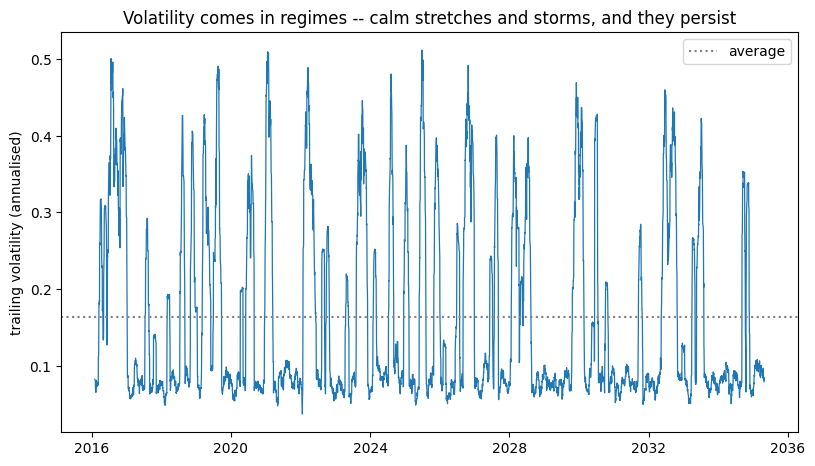

calm-regime days sit near 8% vol; storms near 40%.


In [2]:
rv = vol.realized_vol(ret, window=21) * np.sqrt(252)   # trailing annualised vol
fig, ax = plt.subplots()
ax.plot(rv.index, rv.values, lw=0.9)
ax.axhline(float(rv.mean()), ls=':', c='grey', label='average')
ax.set_ylabel('trailing volatility (annualised)'); ax.legend()
ax.set_title('Volatility comes in regimes -- calm stretches and storms, and they persist')
plt.show()
print(f'calm-regime days sit near {truth.sigma_lo*np.sqrt(252):.0%} vol; storms near {truth.sigma_hi*np.sqrt(252):.0%}.')

## 2 · So what? 💰

If risk is predictable and return isn't, a quiet edge falls out for free. In the stormy stretches you're carrying way more risk for the *same* expected reward — a terrible deal. Down-size there and up-size in the calm, and you spend your risk budget where it's best paid. You never forecast a price; you just **refuse to be maximally exposed into a storm.** The prize is two things every investor actually feels: a higher Sharpe (more return per unit of worry) and — the visceral one — **much shallower crashes**.

## 3 · How we'd know 🔬

Five checks, decided up front:

1. **Is variance actually forecastable?** Does this month's volatility predict next month's? If not, the whole idea is dead on arrival.
2. **Does the overlay lift the Sharpe** vs plain buy-&-hold, net of costs?
3. **Does it shrink the drawdowns** — the part you feel?
4. **Is the lift statistically real**, or a lucky window? (Spanning alpha + a bootstrap.)
5. **The null:** on a tape with *no* regime (constant vol), the overlay must add **nothing**. If it still 'wins' there, we're fooling ourselves.

**What would make us say "mirage":** an overlay gain that vanishes once costs are charged, *or* that shows up just as strong on the flat-vol null.

## 4 · The teardown 🔧

### 4a · Volatility really is forecastable
Chop the tape into months, take each month's variance, and plot it against the *next* month's. If risk persists, the cloud slopes up — and it does.

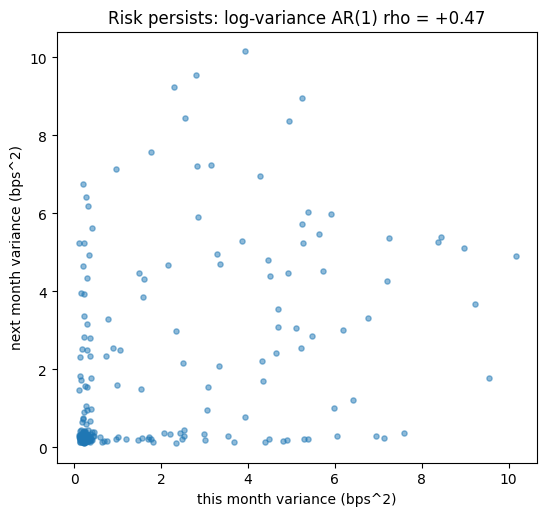

AR(1) rho = +0.47, lag-1 autocorr = +0.43 -- high: today's volatility forecasts tomorrow's.


In [3]:
f = vol.forecastability(ret, horizon=21)
# scatter: this month's variance vs next month's (the overlay's entire input)
r = ret.to_numpy(); nb = len(r)//21
bv = r[:nb*21].reshape(nb,21).var(axis=1, ddof=1)
fig, ax = plt.subplots(figsize=(6.2,5.6))
ax.scatter(bv[:-1]*1e4, bv[1:]*1e4, s=14, alpha=.5)
ax.set_xlabel('this month variance (bps^2)'); ax.set_ylabel('next month variance (bps^2)')
ax.set_title(f'Risk persists: log-variance AR(1) rho = {f["rho"]:+.2f}')
plt.show()
print(f"AR(1) rho = {f['rho']:+.2f}, lag-1 autocorr = {f['autocorr_lag1']:+.2f} "
      f"-- high: today's volatility forecasts tomorrow's.")

A clear upward tilt. Calm begets calm, storm begets storm. *That* — not any view on prices — is the only thing the overlay needs.

### 4b · Sizing by inverse-vol lifts the curve
Now run the rule: each day, hold `target_vol / recent_vol` (using only *past* data), and compare the equity curve to buy-&-hold.

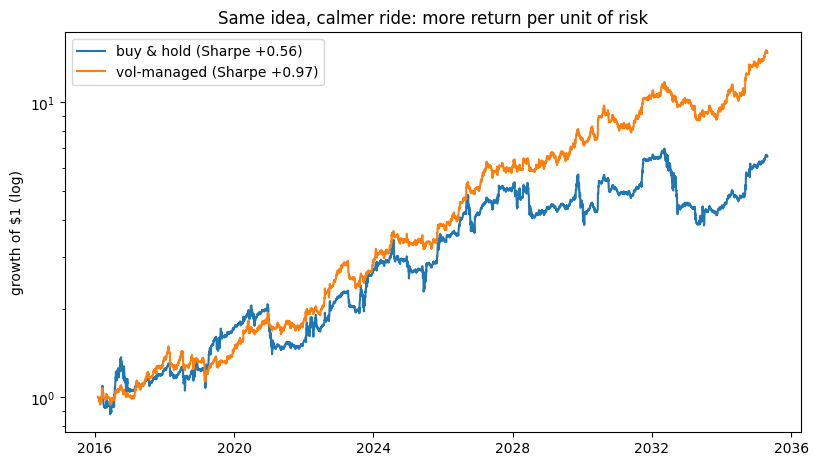

Sharpe +0.56 -> +0.97 (gain +0.41); average leverage 1.13, turnover 12x/yr.


In [4]:
cmp = strategy.compare(ret, cost_bps=1.0)
managed = strategy.managed_returns(ret, cost_bps=1.0)
bh = ret.reindex(managed.index)
eq_bh = (1+bh).cumprod(); eq_mg = (1+managed).cumprod()
fig, ax = plt.subplots()
ax.plot(eq_bh.index, eq_bh.values, label=f"buy & hold (Sharpe {cmp['buy_hold']['sharpe']:+.2f})")
ax.plot(eq_mg.index, eq_mg.values, label=f"vol-managed (Sharpe {cmp['managed_net']['sharpe']:+.2f})")
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.legend()
ax.set_title('Same idea, calmer ride: more return per unit of risk')
plt.show()
print(f"Sharpe {cmp['buy_hold']['sharpe']:+.2f} -> {cmp['managed_net']['sharpe']:+.2f} "
      f"(gain {cmp['sharpe_gain_net']:+.2f}); average leverage {cmp['avg_leverage']:.2f}, "
      f"turnover {cmp['turnover_ann']:.0f}x/yr.")

### 4c · The part you actually feel: drawdowns
Sharpe is abstract. The drawdown — how far underwater you go — is what makes people capitulate at the bottom. Sizing down into storms is *exactly* when it helps most.

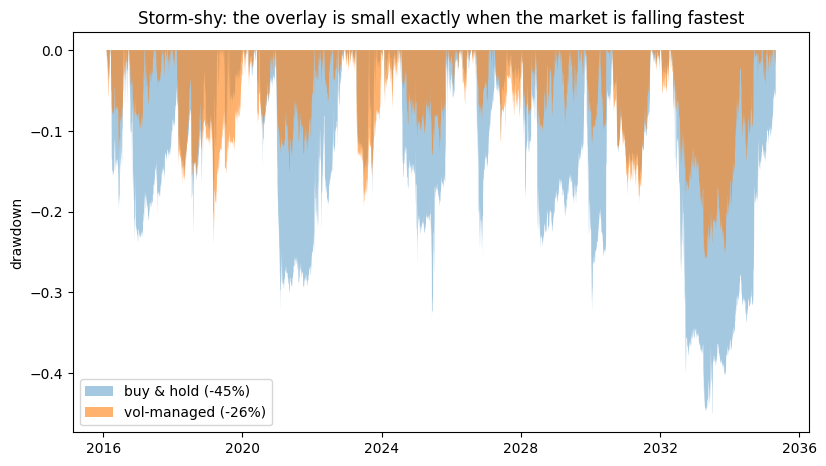

In [5]:
def dd(x): e=(1+x).cumprod(); return e/e.cummax()-1
fig, ax = plt.subplots()
ax.fill_between(bh.index, dd(bh).values, 0, alpha=.4, label=f"buy & hold ({dd(bh).min():.0%})")
ax.fill_between(managed.index, dd(managed).values, 0, alpha=.6, label=f"vol-managed ({dd(managed).min():.0%})")
ax.set_ylabel('drawdown'); ax.legend()
ax.set_title('Storm-shy: the overlay is small exactly when the market is falling fastest')
plt.show()

On the real tape this is the headline a human remembers: SPY's worst drawdown goes from **-55% to -39%**, and QQQ — which lived through the dot-com collapse — from a portfolio-ending **-83% to -38%**.

### 4d · Is the lift real, or a lucky decade?
Two quick gut-checks: a regression that asks whether the managed stream earns something buy-&-hold *can't* replicate (a positive "alpha"), and a bootstrap that re-deals the history thousands of times to see if the Sharpe gain holds up.

In [6]:
sp = decompose.spanning_alpha(ret, cost_bps=1.0)
bs = decompose.sharpe_gain_bootstrap(ret, n_boot=2000, seed=0, cost_bps=1.0)
print(f"spanning alpha {sp['alpha_ann_pct']:+.2f}%/yr, HAC t = {sp['alpha_t']:+.2f} "
      f"(t>2 => not just luck)")
print(f"bootstrap Sharpe gain {bs['sharpe_gain']:+.2f}, 95% CI "
      f"[{bs['ci_low']:+.2f}, {bs['ci_high']:+.2f}], P(gain<0) = {bs['frac_negative']:.1%}")

spanning alpha +8.08%/yr, HAC t = +3.88 (t>2 => not just luck)
bootstrap Sharpe gain +0.41, 95% CI [+0.14, +0.67], P(gain<0) = 0.1%


### 4e · The null — when there's no storm to dodge
The honest control. Re-run everything on a tape with **constant** volatility — no regime, nothing to forecast. If the overlay is real, it should now do **nothing**.

In [7]:
cmp_flat = strategy.compare(ret_flat, cost_bps=1.0)
f_flat = vol.forecastability(ret_flat, horizon=21)
print(f"flat-vol null: variance AR(1) rho = {f_flat['rho']:+.2f} (no persistence to read)")
print(f"               Sharpe gain = {cmp_flat['sharpe_gain_net']:+.2f} (vanishes -- as it must)")
print(f"clustered tape: rho = {vol.forecastability(ret,horizon=21)['rho']:+.2f}, "
      f"Sharpe gain = {cmp['sharpe_gain_net']:+.2f}")

flat-vol null: variance AR(1) rho = -0.00 (no persistence to read)
               Sharpe gain = -0.02 (vanishes -- as it must)
clustered tape: rho = +0.47, Sharpe gain = +0.41


There it is: kill the regime and the edge evaporates. The win comes from the volatility *clustering*, not from the machinery — exactly what a real effect should do.

## 5 · The verdict 🧾

- **Risk is forecastable** (synthetic AR(1) ρ ≈ 0.5; real SPY/QQQ ρ ≈ +0.66/+0.74) — the engine is real and replicated.
- **The overlay pays**: on real SPY the Sharpe goes +0.65 → +0.76, on QQQ +0.51 → +0.77, with drawdowns cut hard — and a spanning alpha that's HAC-significant on both (t = 2.38 / 3.54).
- **The null behaves**: no regime ⇒ no gain.

> **Signal `REAL`.** After fifteen mirages, a genuine, stable, decades-long effect — because it forecasts *risk*, not *returns*. The real-tape numbers and fingerprints are in [`../docs/results.md`](../docs/results.md).

## 6 · Could you trade it? 💸

This is the beat that usually kills a 'real' signal on this desk — and the first time it *doesn't*. Three reasons:

- **Turnover is tiny** (~9×/yr). The vol forecast moves slowly, so you rebalance gently — a few bps of cost against a break-even far above it. Watch the edge barely flinch as costs rise:


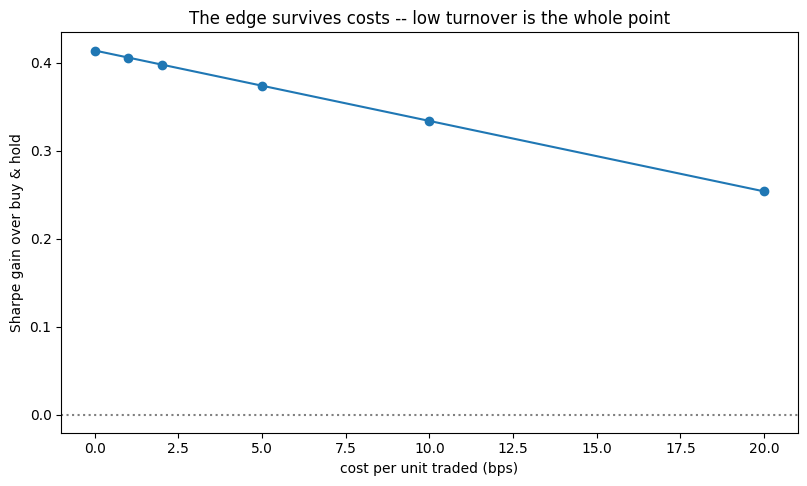

In [8]:
sweep = strategy.cost_sweep(ret)
fig, ax = plt.subplots()
ax.plot(sweep.index, sweep['sharpe_gain'].values, 'o-')
ax.axhline(0, ls=':', c='grey'); ax.set_xlabel('cost per unit traded (bps)')
ax.set_ylabel('Sharpe gain over buy & hold')
ax.set_title('The edge survives costs -- low turnover is the whole point')
plt.show()

- **It scales.** You're sizing an *index* — the most liquid instrument on earth (SPY, ES futures). The ~\$10M capacity walls that sank earlier studies don't apply; this is how multi-billion vol-target and risk-parity funds actually run.
- **The honest catch.** It is **not** a free lunch, and we won't sell it as one. The gain is *risk management*: to hold your risk target in calm times you must take **leverage**, and a strict risk-averse (CRRA) investor, judged at matched risk, banks a **smaller** number than the headline Sharpe suggests (real CE gain ≈ +2.11%/yr on SPY, +6.92%/yr on QQQ). Positive, real, bounded.

> Tradability: a genuine **`INVESTABLE`** — the desk's first. Free lunch? **`RISK-MANAGED`**.

## 7 · Going further 🚪

- **Build the vol forecast better.** We used a plain 21-day window. Does a GARCH or EWMA forecast (already in [`vol.ewma_vol`](../storm_shy/vol.py)) tighten the ride further — or is the simple window 90% of the prize?
- **Across asset classes.** Vol-targeting is strongest where vol-of-vol is high. Bonds, commodities, FX, crypto — where does it help most, and where does the leverage it demands become unrealistic?
- **The leverage constraint, taken seriously.** Cap leverage at 1.0 (no borrowing): how much of the gain is left when you can only ever *de*-risk? That's the version a fund without a financing desk actually lives.

PRs welcome — push the honest 'yes' harder, or find the regime where even this one breaks.